# ------------------------------
# Mumbai House Price Prediction
# ------------------------------
# Author: [Amritanshu]
# Date: [Nov'2025]
# Description: This script loads real estate data from Mumbai,
# preprocesses categorical features, builds an Catboost regression model,
# evaluates performance, and enables future price predictions.
# ------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder

In [2]:
df = pd.read_csv('Mumbai House Prices.csv')

In [3]:
df.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


#  Convert Price to Crores

In [5]:
def price_final(price, price_unit):
    if price_unit == 'L':
        return price / 100  # since 1 Cr = 100 L
    elif price_unit == 'Cr':
        return price        # already in Cr
    else:
        return price / 1e7 

In [6]:
df['price_in_rupees (in Crs)'] = df.apply(lambda row: price_final(row['price'], row['price_unit']), axis=1)
df.drop(columns=['price', 'price_unit'], inplace=True)

In [7]:
df.head()

,bhk,type,locality,area,region,status,age,price_in_rupees (in Crs)
0,3,Apartment,Lak And Hanware The Residency Tower,685,Andheri West,Ready to move,New,2.5000
1,2,Apartment,Radheya Sai Enclave Building No 2,640,Naigaon East,Under Construction,New,0.5251
2,2,Apartment,Romell Serene,610,Borivali West,Under Construction,New,1.7300
3,2,Apartment,Soundlines Codename Urban Rainforest,876,Panvel,Under Construction,New,0.5998
4,2,Apartment,Origin Oriana,659,Mira Road East,Under Construction,New,0.9411


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bhk                       76038 non-null  int64  
 1   type                      76038 non-null  object 
 2   locality                  76038 non-null  object 
 3   area                      76038 non-null  int64  
 4   region                    76038 non-null  object 
 5   status                    76038 non-null  object 
 6   age                       76038 non-null  object 
 7   price_in_rupees (in Crs)  76038 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 4.6+ MB


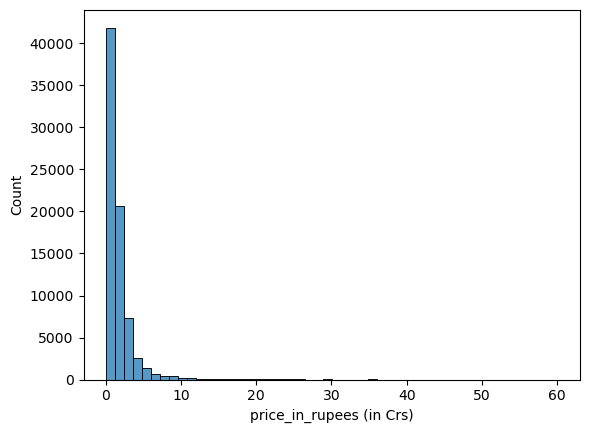

In [9]:
sns.histplot(df['price_in_rupees (in Crs)'], bins=50)
plt.show()

In [10]:
df['price_in_rupees (in Crs)'].describe()

count    76038.000000
mean         1.684178
std          2.176655
min          0.044900
25%          0.640000
50%          1.100000
75%          1.940000
max         60.000000
Name: price_in_rupees (in Crs), dtype: float64

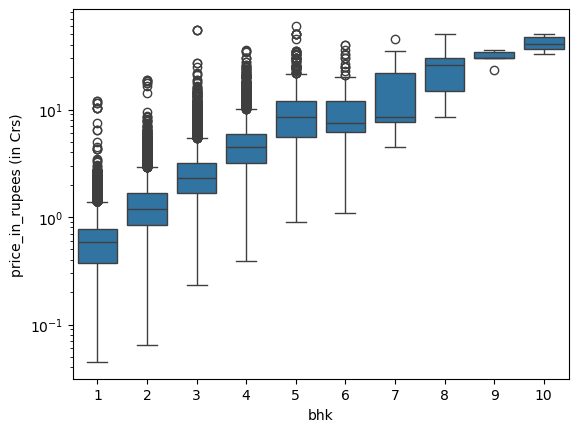

In [11]:
sns.boxplot(x='bhk', y='price_in_rupees (in Crs)', data=df)
plt.yscale('log')
plt.show()

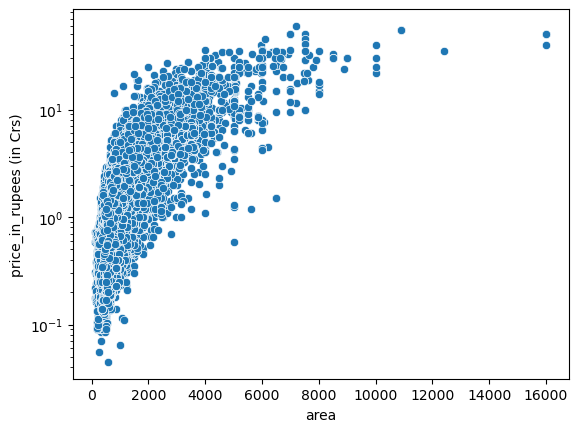

In [12]:
sns.scatterplot(x='area', y='price_in_rupees (in Crs)', data=df)
plt.yscale('log')
plt.show()

In [13]:
df.groupby('locality')['price_in_rupees (in Crs)'].median().sort_values(ascending=False).head(20)

locality
Anchor Daewoo South Ridge                                                    60.0
Indiabulls Blu Tower C                                                       50.5
Lodha Costiera                                                               45.0
Reputed Builder Ram Niwas                                                    36.0
Reputed Builder Avighna                                                      35.0
Arkade Rise                                                                  35.0
Emgee Vikas Park                                                             33.5
Reputed Builder Varsha Apartments                                            33.5
Sunteck Signature Island                                                     32.5
Wadhwa Juhu Anmol Chs                                                        32.0
Provenance Four Seasons Private Residences                                   31.5
Residence                                                                    30.0
Ahuja P

In [14]:
df.groupby('region')['price_in_rupees (in Crs)'].median().sort_values()

region
Khatiwali           0.0900
Versova             0.1250
Vevoor              0.1400
Umroli              0.1462
Dombivli (West)     0.1500
                    ...   
Bandra             10.6000
Babulnath Road     11.4000
Napeansea Road     15.0000
Peddar Road        19.5000
Malabar Hill       27.5000
Name: price_in_rupees (in Crs), Length: 228, dtype: float64

In [15]:
df[['bhk','area','price_in_rupees (in Crs)']].corr()

,bhk,area,price_in_rupees (in Crs)
bhk,1.000000,0.787738,0.631353
area,0.787738,1.000000,0.756000
price_in_rupees (in Crs),0.631353,0.756000,1.000000


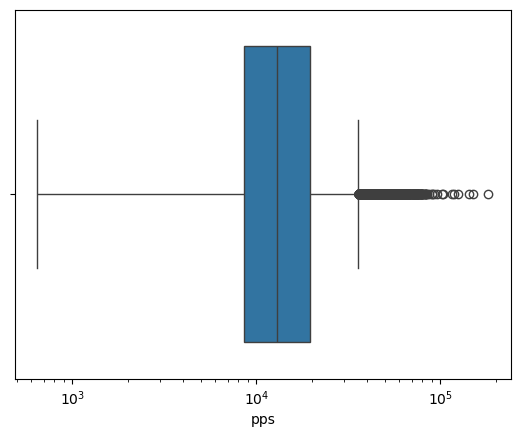

In [16]:
df['pps'] = (df['price_in_rupees (in Crs)'] * 1e7) / df['area'] # Price per square foot
sns.boxplot(x=df['pps'])
plt.xscale('log')
plt.show()


Anything below ₹2,500/sqft in Mumbai is basically imaginary.
Anything above ₹1,50,000/sqft is likely misreported.

In [17]:
df = df[(df['pps'] > 2500) & (df['pps'] < 150000)]

In [18]:
df.groupby('locality')['pps'].median().sort_values(ascending=False).head(20)

locality
Swaraj Homes Gold Mist Apartments       118750.000000
Lakhani Signature                        86538.461538
Reputed Builder Pali Heights             83333.333333
Anchor Daewoo South Ridge                83333.333333
Reputed Builder Jivesh Terraces          83142.857143
Joy Legend                               80000.000000
Supreme Waterfront Heights               79979.845482
Reputed Builder Silver Cascade           77272.727273
Reputed Builder Shubhada Towers          75000.000000
Lodha Altamount                          74829.931973
Reputed Builder Beaumonde Towers         73913.043478
Swaraj Homes Midtown Apartment           73809.523810
Wadhwa Juhu Anmol Chs                    73563.218391
Park Reach                               73103.448276
Raheja Sunkist                           73076.923077
Aanandvardhan Om Swami Anand             72859.744991
Indiabulls Blu Tower C                   72142.857143
Ajit Barve Anand Heights                 71856.287425
Joy Legend Wing B  

In [19]:
df.groupby('locality')['pps'].median().sort_values().head(20)

locality
Reputed Builder Sai Nirman                    2537.500000
Yashwant Shree Mani Bhadra CHS                2542.372881
SPS White Orchid                              2551.020408
Reputed Builder Sai Leela Apartment           2586.206897
Mohan Water Edge                              2600.000000
Sai Ram Residency                             2619.117647
Tata Shubh Griha                              2621.257832
Saidhara Sai Park                             2649.786325
Shree Sai Apartment                           2659.813084
Green Riddhish Apartment                      2666.666667
Aditya Creations The Ocean Homes The Pearl    2694.757472
Signature Signature The Morning               2741.935484
Reputed Builder Mansi Vihar                   2750.000000
Creative Symphony                             2757.619739
Swastik Parvati Garden                        2759.289617
Yash Manjiri Heights                          2770.270270
Swastik Parvati Darshan Apartment Wing A      2772.826087
Mahal

In [20]:
#This will clean the bottom garbage while keeping premium localities intact.
df = df[df['pps'] > 3000]

In [21]:
print(df['age'].value_counts())
print(df['region'].value_counts())
print(df['status'].value_counts())

age
New        37981
Resale     23280
Unknown    14547
Name: count, dtype: int64
region
Thane West             14863
Mira Road East          9901
Dombivali               3038
Kandivali East          2568
Kharghar                2360
                       ...  
Juhu Scheme                1
Sector-4 New Panvel        1
Adaigaon                   1
Sector 6 Kamothe           1
Pen                        1
Name: count, Length: 225, dtype: int64
status
Ready to move         44812
Under Construction    30996
Name: count, dtype: int64


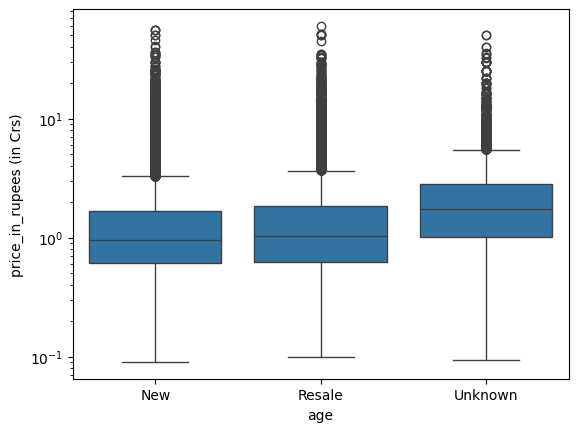

In [22]:
sns.boxplot(x='age', y='price_in_rupees (in Crs)', data=df)
plt.yscale('log')
plt.show()

In [23]:
age_map = {'Resale': 0, 'New': 1, 'Unknown': 2}
df['age_encoded'] = df['age'].map(age_map)
df.drop(columns=['age'], inplace=True)

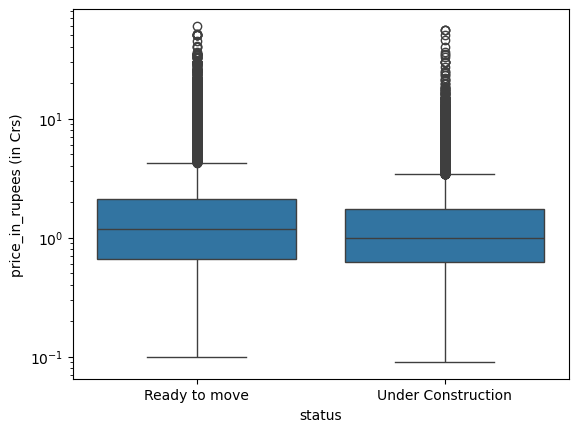

In [24]:
sns.boxplot(x='status', y='price_in_rupees (in Crs)', data=df)
plt.yscale('log')
plt.show()

In [25]:
df['status_encoded'] = (df['status'] == 'Ready to move').astype(int)
df.drop(columns=['status'], inplace=True)

In [26]:
df['region_freq'] = df['region'].map(df['region'].value_counts())
df['locality_freq'] = df['locality'].map(df['locality'].value_counts())

In [27]:
region_freq = df['region'].value_counts().to_dict()
locality_freq = df['locality'].value_counts().to_dict()

In [28]:
df.head()

,bhk,type,locality,area,region,price_in_rupees (in Crs),pps,age_encoded,status_encoded,region_freq,locality_freq
0,3,Apartment,Lak And Hanware The Residency Tower,685,Andheri West,2.5000,36496.350365,1,1,1841,10
1,2,Apartment,Radheya Sai Enclave Building No 2,640,Naigaon East,0.5251,8204.687500,1,0,845,8
2,2,Apartment,Romell Serene,610,Borivali West,1.7300,28360.655738,1,0,881,13
3,2,Apartment,Soundlines Codename Urban Rainforest,876,Panvel,0.5998,6847.031963,1,0,1474,2
4,2,Apartment,Origin Oriana,659,Mira Road East,0.9411,14280.728376,1,0,9901,12


In [29]:
df[['bhk','area','pps','age_encoded','status_encoded',
    'price_in_rupees (in Crs)']].corr()

,bhk,area,pps,age_encoded,status_encoded,price_in_rupees (in Crs)
bhk,1.000000,0.788302,0.363084,0.189854,0.127031,0.631620
area,0.788302,1.000000,0.217256,0.156499,0.235437,0.758139
pps,0.363084,0.217256,1.000000,0.040321,-0.117095,0.664040
age_encoded,0.189854,0.156499,0.040321,1.000000,-0.272414,0.073217
status_encoded,0.127031,0.235437,-0.117095,-0.272414,1.000000,0.088338
price_in_rupees (in Crs),0.631620,0.758139,0.664040,0.073217,0.088338,1.000000


In [30]:
features = [
    'bhk',
    'area',
    'pps',
    'age_encoded',
    'status_encoded'
]

X = df[features]
y = df['price_in_rupees (in Crs)']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_lr
print(f'RMSE of Linear Regression: {rmse_lr}')

RMSE of Linear Regression: 0.7780459965054376


In [33]:
from catboost import CatBoostRegressor

In [34]:
# log target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

cat_log = CatBoostRegressor(
    iterations=1300,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,#regularization parameter that controls how complex the model can become by penalizing large values in leaf nodes.
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

cat_log.fit(X_train, y_train_log, eval_set=(X_test, y_test_log)) #log1p on both training and test data to stabilize variance, reduce the effect of extreme values,


pred_log = cat_log.predict(X_test)
pred = np.expm1(pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test, pred))
print(f'RMSE of Tuned CatBoost Regressor: {rmse_log}')

RMSE of Tuned CatBoost Regressor: 0.16898664060651067


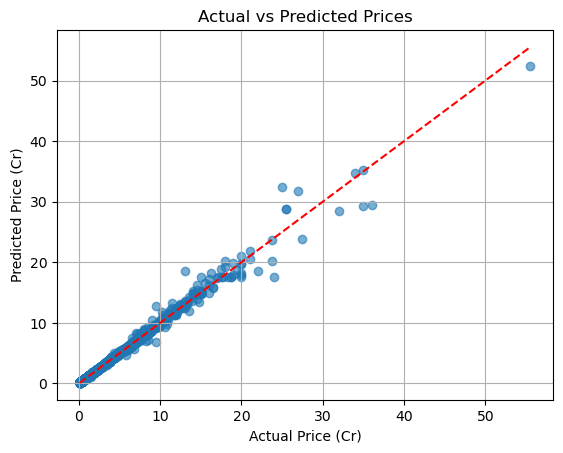

In [35]:
pred = np.expm1(pred_log)  # inverse of log1p
plt.scatter(y_test, pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price (Cr)")
plt.ylabel("Predicted Price (Cr)")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()

In [36]:
import joblib
joblib.dump(cat_log, "mumbai_house_model.pkl")
joblib.dump(region_freq, "region_freq.pkl")
joblib.dump(locality_freq, "locality_freq.pkl")

['locality_freq.pkl']